---
## Next: Model 3 of 5 — Cell Segmentation (U-Net on SegPC-2021 / Raabin-WBC)

Say **"build model 3"** and I'll produce that notebook next — U-Net with Dice+BCE loss, IoU/Dice evaluation, mask overlays, and morphological feature extraction (area, circularity, N/C ratio) that Model 5 needs later.

**Notes for your write-up:**
- State the exact BCCD version/source URL and download date in your Methods — Roboflow dataset versions get updated, so reproducibility requires pinning it.
- mAP50-95 is the stricter, IoU-averaged metric — report both mAP50 and mAP50-95, reviewers expect it.
- If platelet AP is noticeably lower than RBC/WBC (common — platelets are small and easy to miss), flag it explicitly; that's a legitimate finding to discuss, not a bug to hide.


In [ ]:
# 1. Environment setup
!pip install -q segmentation-models-pytorch albumentations datasets pillow

import os, random, json, glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00
Device: cuda


In [ ]:
# 2. Dataset — zxaoyou/segmentation_WBC (GitHub, public, no key needed)
# Classic WBC segmentation benchmark: Dataset 1 (300 imgs) + Dataset 2 (100 imgs)
# Masks: white=nucleus, gray=cytoplasm, black=background/RBC

!git clone -q https://github.com/zxaoyou/segmentation_WBC.git
!find segmentation_WBC -maxdepth 2 -type d

segmentation_WBC
segmentation_WBC/Dataset 2
segmentation_WBC/.git
segmentation_WBC/.git/info
segmentation_WBC/.git/logs
segmentation_WBC/.git/hooks
segmentation_WBC/.git/refs
segmentation_WBC/.git/objects
segmentation_WBC/.git/branches
segmentation_WBC/Dataset 1


In [ ]:
# 3. Inspect structure before writing conversion logic
import glob

for root_dir in glob.glob('segmentation_WBC/*'):
    print(root_dir)
    files_here = glob.glob(f'{root_dir}/*')[:5]
    for f in files_here:
        print('   ', f)

segmentation_WBC/Class Labels of Dataset 2.csv
segmentation_WBC/Dataset 1.png
segmentation_WBC/LICENSE
segmentation_WBC/Dataset 2.png
segmentation_WBC/Dataset 2
    segmentation_WBC/Dataset 2/028.bmp
    segmentation_WBC/Dataset 2/075.bmp
    segmentation_WBC/Dataset 2/030.bmp
    segmentation_WBC/Dataset 2/061.png
    segmentation_WBC/Dataset 2/011.png
segmentation_WBC/README.rst
segmentation_WBC/Dataset 1
    segmentation_WBC/Dataset 1/028.bmp
    segmentation_WBC/Dataset 1/205.png
    segmentation_WBC/Dataset 1/288.bmp
    segmentation_WBC/Dataset 1/075.bmp
    segmentation_WBC/Dataset 1/285.png
segmentation_WBC/Class Labels of Dataset 1.csv


In [ ]:
# 4. Pair images (.bmp) with masks (.png) and inspect actual pixel values used
import numpy as np
from PIL import Image
from pathlib import Path

def build_pairs(dataset_dir):
    d = Path(dataset_dir)
    bmp_files = sorted(d.glob('*.bmp'))
    pairs = []
    for bmp in bmp_files:
        png = d / f"{bmp.stem}.png"
        if png.exists():
            pairs.append((str(bmp), str(png)))
    return pairs

pairs_ds1 = build_pairs('segmentation_WBC/Dataset 1')
pairs_ds2 = build_pairs('segmentation_WBC/Dataset 2')
print(f"Dataset 1 pairs: {len(pairs_ds1)}")
print(f"Dataset 2 pairs: {len(pairs_ds2)}")

# Inspect one mask's actual pixel values
sample_mask = np.array(Image.open(pairs_ds1[0][1]))
print("\nSample mask shape:", sample_mask.shape)
print("Sample mask dtype:", sample_mask.dtype)
print("Unique values/colors in mask:")
if sample_mask.ndim == 2:
    print(np.unique(sample_mask))
else:
    print(np.unique(sample_mask.reshape(-1, sample_mask.shape[-1]), axis=0))

Dataset 1 pairs: 300
Dataset 2 pairs: 100

Sample mask shape: (120, 120)
Sample mask dtype: uint8
Unique values/colors in mask:
[  0 128 255]


In [ ]:
# 5. Dataset class — maps mask values {0,128,255} -> class indices {0,1,2}
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

IMG_SIZE = 224
VALUE_TO_CLASS = {0: 0, 128: 1, 255: 2}  # background, cytoplasm, nucleus
CLASS_NAMES = ['background', 'cytoplasm', 'nucleus']

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class WBCSegDataset(Dataset):
    def __init__(self, pairs, transform):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask_raw = np.array(Image.open(mask_path))

        mask = np.zeros_like(mask_raw, dtype=np.int64)
        for val, cls in VALUE_TO_CLASS.items():
            mask[mask_raw == val] = cls

        augmented = self.transform(image=img, mask=mask)
        return augmented['image'], augmented['mask'].long()

Total pairs: 400
Train: 280 | Val: 60 | Test: 60


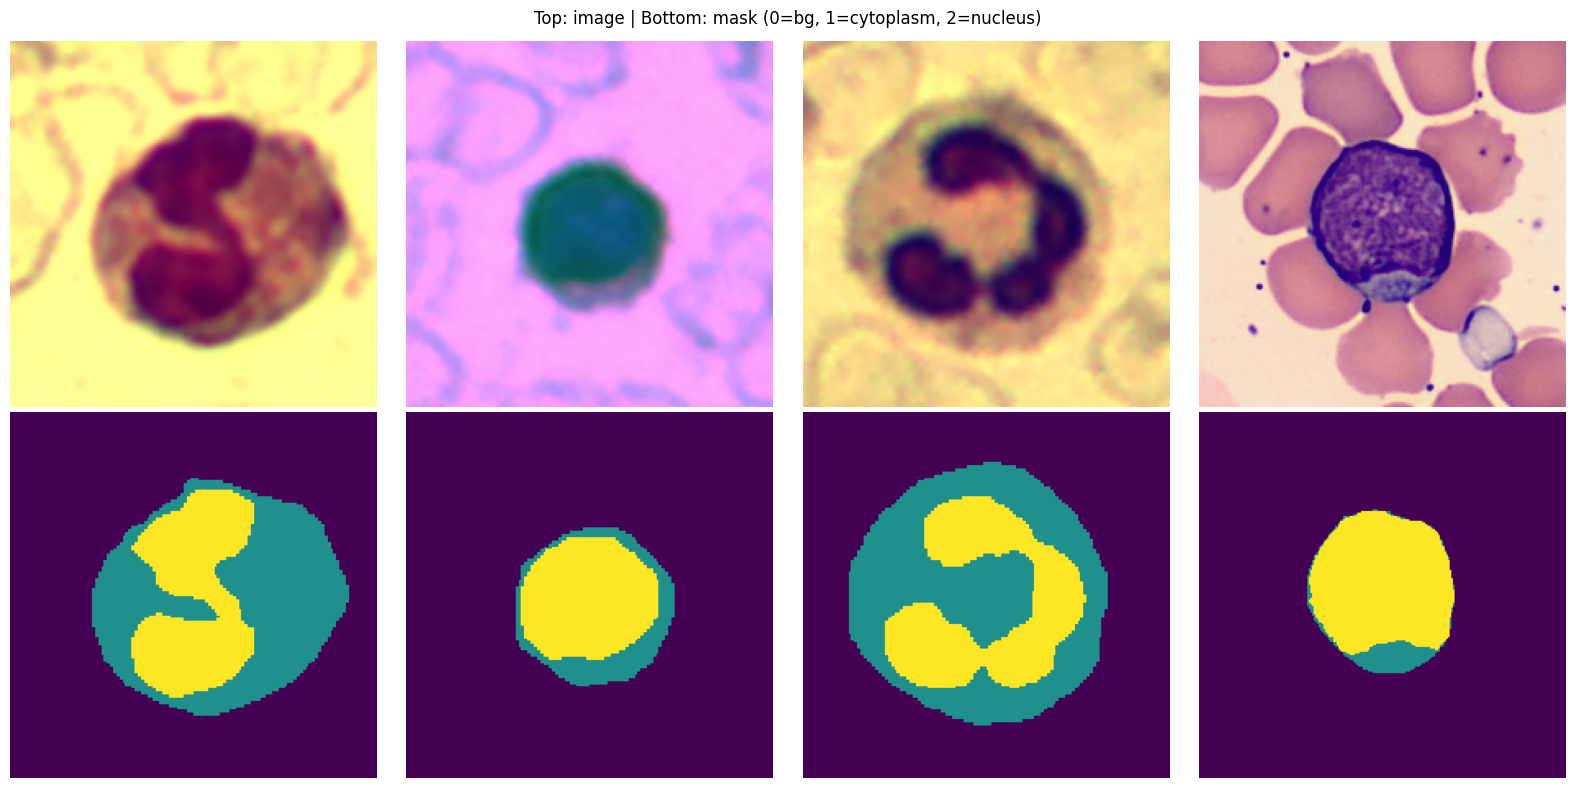

In [ ]:
# 6. Split (combine both datasets — Dataset 1 is the main 300, Dataset 2 adds domain diversity)
from sklearn.model_selection import train_test_split

all_pairs = pairs_ds1 + pairs_ds2
print(f"Total pairs: {len(all_pairs)}")

train_pairs, temp_pairs = train_test_split(all_pairs, test_size=0.3, random_state=42)
val_pairs, test_pairs = train_test_split(temp_pairs, test_size=0.5, random_state=42)
print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

train_ds = WBCSegDataset(train_pairs, train_tfms)
val_ds = WBCSegDataset(val_pairs, eval_tfms)
test_ds = WBCSegDataset(test_pairs, eval_tfms)

BATCH_SIZE = 16
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Sanity check visualization
fig, axes = plt.subplots(2, 4, figsize=(16,8))
for i in range(4):
    img, mask = train_ds[i]
    img_np = img.permute(1,2,0).numpy()
    img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    axes[0,i].imshow(np.clip(img_np,0,1)); axes[0,i].axis('off')
    axes[1,i].imshow(mask.numpy(), cmap='viridis', vmin=0, vmax=2); axes[1,i].axis('off')
plt.suptitle('Top: image | Bottom: mask (0=bg, 1=cytoplasm, 2=nucleus)')
plt.tight_layout()
plt.show()

In [ ]:
# 7. U-Net with pretrained ResNet34 encoder (transfer learning, not from scratch)
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=len(CLASS_NAMES),
).to(device)

print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Model params: 24,436,659


In [ ]:
# 8. Combined Dice + CE loss
class DiceCELoss(nn.Module):
    def __init__(self, num_classes, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.num_classes = num_classes
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def dice_loss(self, logits, targets, smooth=1e-5):
        probs = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        dims = (0,2,3)
        intersection = torch.sum(probs * targets_onehot, dims)
        cardinality = torch.sum(probs + targets_onehot, dims)
        dice = (2. * intersection + smooth) / (cardinality + smooth)
        return 1 - dice.mean()

    def forward(self, logits, targets):
        return self.ce_weight * self.ce(logits, targets) + self.dice_weight * self.dice_loss(logits, targets)

criterion = DiceCELoss(num_classes=len(CLASS_NAMES))

In [ ]:
# 9. Training loop
from tqdm.auto import tqdm

def compute_iou_dice(preds, targets, num_classes):
    ious, dices = [], []
    for cls in range(num_classes):
        pred_cls = (preds == cls)
        target_cls = (targets == cls)
        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()
        iou = intersection / union if union > 0 else float('nan')
        dice = (2*intersection) / (pred_cls.sum().item() + target_cls.sum().item()) if (pred_cls.sum().item() + target_cls.sum().item()) > 0 else float('nan')
        ious.append(iou); dices.append(dice)
    return ious, dices

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0
    all_ious, all_dices = [], []

    with torch.set_grad_enabled(is_train):
        for x, y in tqdm(dataloader, leave=False):
            x, y = x.to(device), y.to(device)
            if is_train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)

            preds = out.argmax(1)
            ious, dices = compute_iou_dice(preds, y, len(CLASS_NAMES))
            all_ious.append(ious); all_dices.append(dices)

    mean_iou = np.nanmean(all_ious, axis=0)
    mean_dice = np.nanmean(all_dices, axis=0)
    return total_loss / len(dataloader.dataset), mean_iou, mean_dice

EPOCHS = 60
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_dice, patience_ctr, patience = 0, 0, 10
history = {'train_loss': [], 'val_loss': [], 'val_dice_mean': []}

for epoch in range(EPOCHS):
    tr_loss, tr_iou, tr_dice = run_epoch(model, train_dl, criterion, optimizer)
    val_loss, val_iou, val_dice = run_epoch(model, val_dl, criterion)
    scheduler.step()

    val_dice_mean = np.mean(val_dice)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_dice_mean'].append(val_dice_mean)

    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_dice(bg/cyto/nuc)={val_dice[0]:.3f}/{val_dice[1]:.3f}/{val_dice[2]:.3f} | mean={val_dice_mean:.4f}")

    if val_dice_mean > best_val_dice:
        best_val_dice = val_dice_mean
        patience_ctr = 0
        torch.save(model.state_dict(), 'unet_best.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('unet_best.pt'))
print(f"\nBest val Dice (mean): {best_val_dice:.4f}")

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/60 | train_loss=0.7786 | val_loss=0.7538 | val_dice(bg/cyto/nuc)=0.833/0.249/0.483 | mean=0.5217


  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x798101b7d3a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^

  0%|          | 0/18 [00:00<?, ?it/s]

^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x798101b7d3a0>

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    assert self._parent_pid == os.getpid(), 'can only test a child process'
self._shutdown_workers()
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
           ^^ ^^ ^^^^^^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^ ^ ^ ^ ^ ^ ^ ^ ^^  ^
AssertionError^: can only test a child process^
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 50/60 | train_loss=0.0552 | val_loss=0.0557 | val_dice(bg/cyto/nuc)=0.993/0.947/0.967 | mean=0.9690
Early stopping at epoch 50

Best val Dice (mean): 0.9695


In [ ]:
# 10. Final test evaluation
test_loss, test_iou, test_dice = run_epoch(model, test_dl, criterion)

print("=== Test Set Results ===")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:12s} | IoU: {test_iou[i]:.4f} | Dice: {test_dice[i]:.4f}")
print(f"\nMean IoU:  {np.mean(test_iou):.4f}")
print(f"Mean Dice: {np.mean(test_dice):.4f}")

  0%|          | 0/4 [00:00<?, ?it/s]

=== Test Set Results ===
background   | IoU: 0.9868 | Dice: 0.9934
cytoplasm    | IoU: 0.9045 | Dice: 0.9498
nucleus      | IoU: 0.9441 | Dice: 0.9712

Mean IoU:  0.9451
Mean Dice: 0.9715


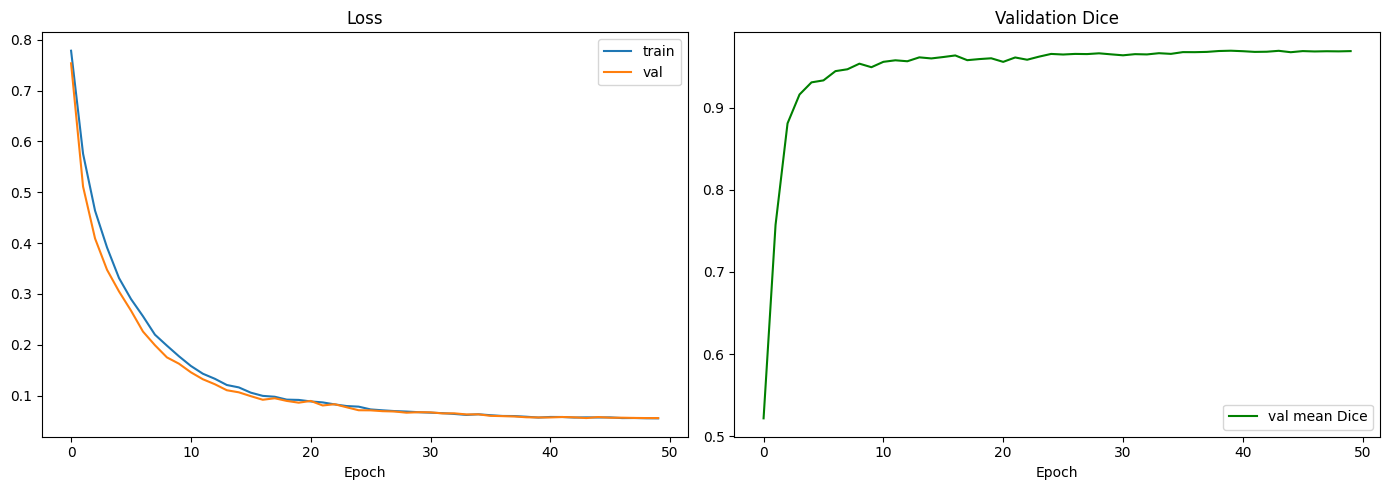

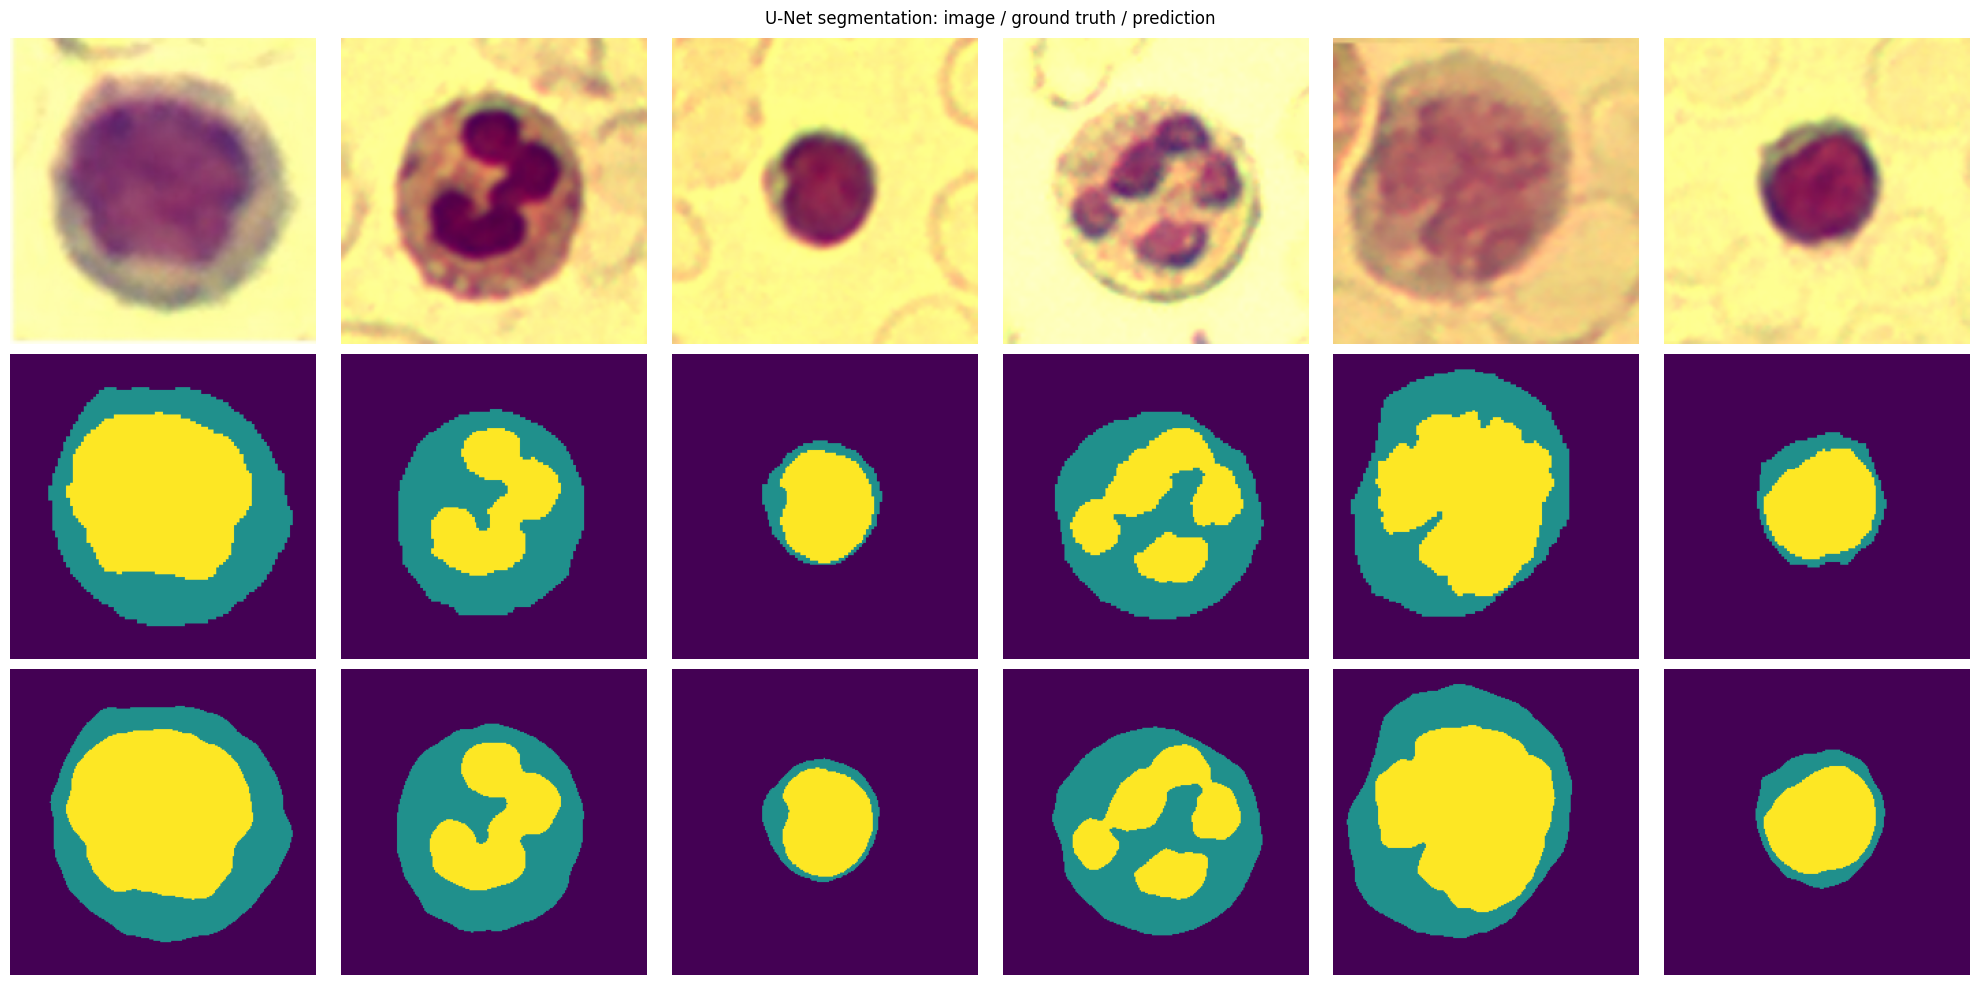

In [ ]:
# 11. Plots
fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(history['val_dice_mean'], label='val mean Dice', color='green')
axes[1].set_title('Validation Dice'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout()
plt.savefig('unet_training_curves.png', dpi=150)
plt.show()

# Visual predictions
model.eval()
sample_x, sample_y = next(iter(test_dl))
sample_x = sample_x.to(device)
with torch.no_grad():
    preds = model(sample_x).argmax(1).cpu()

fig, axes = plt.subplots(3, 6, figsize=(20,10))
for i in range(6):
    img_np = sample_x[i].cpu().permute(1,2,0).numpy()
    img_np = img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
    axes[0,i].imshow(np.clip(img_np,0,1)); axes[0,i].axis('off')
    axes[1,i].imshow(sample_y[i].numpy(), cmap='viridis', vmin=0, vmax=2); axes[1,i].axis('off')
    axes[2,i].imshow(preds[i].numpy(), cmap='viridis', vmin=0, vmax=2); axes[2,i].axis('off')
axes[0,0].set_ylabel('Image'); axes[1,0].set_ylabel('Ground Truth'); axes[2,0].set_ylabel('Prediction')
plt.suptitle('U-Net segmentation: image / ground truth / prediction')
plt.tight_layout()
plt.savefig('unet_predictions.png', dpi=150)
plt.show()

In [ ]:
# 12. Morphological features from predicted masks — cell size, circularity, N/C ratio, etc.
from skimage import measure

def extract_morphological_features(mask, nucleus_val=2, cytoplasm_val=1):
    features = {}
    nucleus_mask = (mask == nucleus_val).astype(np.uint8)
    cell_mask = ((mask == nucleus_val) | (mask == cytoplasm_val)).astype(np.uint8)

    nuc_props = measure.regionprops(measure.label(nucleus_mask))
    cell_props = measure.regionprops(measure.label(cell_mask))

    if nuc_props and cell_props:
        nuc = max(nuc_props, key=lambda p: p.area)
        cell = max(cell_props, key=lambda p: p.area)

        features['nucleus_area'] = nuc.area
        features['cell_area'] = cell.area
        features['nc_ratio'] = nuc.area / cell.area if cell.area > 0 else 0
        features['nucleus_circularity'] = (4 * np.pi * nuc.area) / (nuc.perimeter ** 2) if nuc.perimeter > 0 else 0
        features['nucleus_eccentricity'] = nuc.eccentricity
        features['cell_circularity'] = (4 * np.pi * cell.area) / (cell.perimeter ** 2) if cell.perimeter > 0 else 0
    else:
        features = {k: 0 for k in ['nucleus_area','cell_area','nc_ratio','nucleus_circularity','nucleus_eccentricity','cell_circularity']}
    return features

# Demo on a few test predictions
print("Sample morphological features (from predicted masks):\n")
for i in range(4):
    feats = extract_morphological_features(preds[i].numpy())
    print(f"Sample {i}: {feats}")

Sample morphological features (from predicted masks):

Sample 0: {'nucleus_area': np.float64(13253.0), 'cell_area': np.float64(23868.0), 'nc_ratio': np.float64(0.5552622758505111), 'nucleus_circularity': np.float64(0.8593296210456367), 'nucleus_eccentricity': 0.3974809188486834, 'cell_circularity': np.float64(0.8829236537654073)}
Sample 1: {'nucleus_area': np.float64(5681.0), 'cell_area': np.float64(16460.0), 'nc_ratio': np.float64(0.3451397326852977), 'nucleus_circularity': np.float64(0.3775886872542853), 'nucleus_eccentricity': 0.7600774082906833, 'cell_circularity': np.float64(0.884114229132519)}
Sample 2: {'nucleus_area': np.float64(4194.0), 'cell_area': np.float64(5871.0), 'nc_ratio': np.float64(0.7143587123147676), 'nucleus_circularity': np.float64(0.8514491125724811), 'nucleus_eccentricity': 0.5576589724435189, 'cell_circularity': np.float64(0.9010245714342423)}
Sample 3: {'nucleus_area': np.float64(4620.0), 'cell_area': np.float64(17817.0), 'nc_ratio': np.float64(0.259302912948

In [ ]:
# 13. Package results + download locally
import shutil, json
from google.colab import files

results_summary = {
    'model': 'U-Net (ResNet34 encoder, ImageNet pretrained)',
    'dataset': 'zxaoyou/segmentation_WBC (Dataset 1 + 2)',
    'classes': CLASS_NAMES,
    'test_iou_per_class': {CLASS_NAMES[i]: float(test_iou[i]) for i in range(len(CLASS_NAMES))},
    'test_dice_per_class': {CLASS_NAMES[i]: float(test_dice[i]) for i in range(len(CLASS_NAMES))},
    'test_mean_iou': float(np.mean(test_iou)),
    'test_mean_dice': float(np.mean(test_dice)),
    'train_size': len(train_pairs), 'val_size': len(val_pairs), 'test_size': len(test_pairs),
}
with open('model3_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print(json.dumps(results_summary, indent=2))

DOWNLOAD_DIR = Path('/content/model3_download')
DOWNLOAD_DIR.mkdir(exist_ok=True)
for fname in ['unet_best.pt', 'model3_results_summary.json', 'unet_training_curves.png', 'unet_predictions.png']:
    if Path(fname).exists():
        shutil.copy(fname, DOWNLOAD_DIR / fname)

zip_path = shutil.make_archive('/content/model3_cell_segmentation', 'zip', DOWNLOAD_DIR)
print(f"\nZipped to: {zip_path}")
files.download(zip_path)

{
  "model": "U-Net (ResNet34 encoder, ImageNet pretrained)",
  "dataset": "zxaoyou/segmentation_WBC (Dataset 1 + 2)",
  "classes": [
    "background",
    "cytoplasm",
    "nucleus"
  ],
  "test_iou_per_class": {
    "background": 0.986813093356186,
    "cytoplasm": 0.9044836671866447,
    "nucleus": 0.9441209841817391
  },
  "test_dice_per_class": {
    "background": 0.993362744223162,
    "cytoplasm": 0.9498453218086367,
    "nucleus": 0.9712454649343287
  },
  "test_mean_iou": 0.9451392482415232,
  "test_mean_dice": 0.9714845103220423,
  "train_size": 280,
  "val_size": 60,
  "test_size": 60
}

Zipped to: /content/model3_cell_segmentation.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>